In [ ]:
import warnings
warnings.filterwarnings("ignore") ## Dọn dẹp và làm sạch màn hình
import pandas as pd ## Thư viện đọc file dữ liệu
import numpy as np ## Thư viện tính toán
import seaborn as sns ## Vẽ các đồ thị
sns.set(style='darkgrid') ## Thiết lập kiểu đồ thị
import matplotlib.pyplot as plt ## Vẽ biểu đồ
import missingno as msno ## Trực quan hóa các giá trị bị thiếu
import os
import glob
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance


In [ ]:
## Kết nối với hệ thống lưu trữ đám mây Google Drive
from google.colab import drive
drive.mount('/content/drive')
data1 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Monday-WorkingHours.pcap_ISCX.csv')
data2 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Tuesday-WorkingHours.pcap_ISCX.csv')
data3 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Wednesday-workingHours.pcap_ISCX.csv')
data4 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data5 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data7 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data8 = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

Mounted at /content/drive


In [ ]:
## Đọc kích thước của các file dữ liệu
data_list = [data1, data2, data3, data4, data5, data6, data7, data8]
print('Kích thước dữ liệu: ')
for i, data in enumerate(data_list, start = 1):
  rows, cols = data.shape
  print(f'Data{i} -> {rows} hàng, {cols} cột')

Kích thước dữ liệu: 
Data1 -> 529918 hàng, 79 cột
Data2 -> 445909 hàng, 79 cột
Data3 -> 692703 hàng, 79 cột
Data4 -> 170366 hàng, 79 cột
Data5 -> 288602 hàng, 79 cột
Data6 -> 191033 hàng, 79 cột
Data7 -> 286467 hàng, 79 cột
Data8 -> 225745 hàng, 79 cột


In [ ]:
## Gộp và đọc các file dữ liệu
data = pd.concat(data_list)
rows, cols = data.shape
print('Kích thước dữ liệu:')
print(f'Số hàng: {rows}')
print(f'Số cột: {cols}')
print(f'Tổng số ô dữ liệu: {rows * cols}')

Kích thước dữ liệu:
Số hàng: 2830743
Số cột: 79
Tổng số ô dữ liệu: 223628697


In [ ]:
## Xóa các ô dữ liệu sau khi gộp để tiết kiệm bộ nhớ
for d in data_list: del d

In [ ]:
## Đổi tên các cột bằng cách loại bỏ các khoảng trắng đầu cuối
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)
data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2830743 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow I

In [ ]:
## Tìm và đếm tổng số dòng dữ liệu bị trùng lặp
dups = data[data.duplicated()]
print(f'Số dòng trùng lặp: {len(dups)}')

Số dòng trùng lặp: 308381


In [ ]:
## Xóa các dòng trùng lặp và in ra số hàng và cột sau khi xóa
data.drop_duplicates(inplace = True)
data.shape

(2522362, 79)

In [ ]:
data.reset_index(drop=True, inplace=True)
print('Chỉ mục đã được đặt lại.')

Chỉ mục đã được đặt lại.


In [ ]:
## Kiểm tra giá trị bị thiếu
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0])

Flow Bytes/s    353
dtype: int64


In [ ]:
## Kiểm tra giá trị vô hạn
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [ ]:
# Thay thế các giá trị vô hạn bằng NaN
print(f'Giá trị ban đầu bị thiếu: {data.isna().sum().sum()}')
data.replace([np.inf, -np.inf], np.nan, inplace = True)
print(f'Giá trị bị thiếu sau khi xử lý các giá trị vô hạn: {data.isna().sum().sum()}')

Giá trị ban đầu bị thiếu: 353
Giá trị bị thiếu sau khi xử lý các giá trị vô hạn: 3128


In [ ]:
## Liệt kê các cột bị thiếu
missing = data.isna().sum()
print(missing.loc[missing > 0])

Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64


In [ ]:
## Phần trăm giá trị bị thiếu trong dataset
mis_per = (missing / len(data)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Giá trị thiếu', 1 : 'Phần trăm trong tổng số giá trị'})
print(mis_table.loc[mis_per > 0])

                Giá trị thiếu  Phần trăm trong tổng số giá trị
Flow Bytes/s             1564                             0.06
Flow Packets/s           1564                             0.06


In [ ]:
med_flow_bytes = data['Flow Bytes/s'].median()
med_flow_packets = data['Flow Packets/s'].median()
print('Trung vị của Flow Bytes/s: ', med_flow_bytes)
print('Trung vị của Flow Packets/s: ', med_flow_packets)

Trung vị của Flow Bytes/s:  3715.0378579999997
Trung vị của Flow Packets/s:  69.742244285


In [ ]:
## Điền các giá trị bị thiếu bằng trung vị
data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
data['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

In [ ]:
print('Số giá trị \'Flow Bytes/s\' bị thiếu:', data['Flow Bytes/s'].isna().sum())
print('Số giá trị \'Flow Packets/s\' bị thiếu:', data['Flow Packets/s'].isna().sum())

Số giá trị 'Flow Bytes/s' bị thiếu: 0
Số giá trị 'Flow Packets/s' bị thiếu: 0


In [ ]:
## Phân tích các mẫu dùng hình ảnh trực quan
data['Label'].unique()

array(['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'Infiltration', 'Bot', 'PortScan',
       'DDoS'], dtype=object)

In [ ]:
## Các trường hợp tấn công và các trường hợp bình thường
data['Label'].value_counts()



,count
Label,
BENIGN,2096484
DoS Hulk,172849
DDoS,128016
PortScan,90819
DoS GoldenEye,10286
FTP-Patator,5933
DoS slowloris,5385
DoS Slowhttptest,5228
SSH-Patator,3219


In [ ]:
## Tạo ánh xạ nhãn với loại tấn công tương ứng
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

## Tạo một cột mới 'Attack Type' trong DataFrame dựa trên từ điển attack_map
data['Attack Type'] = data['Label'].map(attack_map)

In [ ]:
data['Attack Type'].value_counts()

,count
Attack Type,
BENIGN,2096484
DoS,193748
DDoS,128016
Port Scan,90819
Brute Force,9152
Web Attack,2143
Bot,1953
Infiltration,36
Heartbleed,11


In [ ]:
## Xóa bớt để giảm bớt dữ liệu
data.drop('Label', axis = 1, inplace = True)

In [ ]:
## Mã hóa nhãn
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Attack Number'] = le.fit_transform(data['Attack Type'])
print(data['Attack Number'].unique())
## In ra loại tấn công tương ứng cho mỗi giá trị được mã hóa
encoded_values = data['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

[0 2 4 5 8 6 1 7 3]
0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Heartbleed
6: Infiltration
7: Port Scan
8: Web Attack


In [ ]:
## Tính toán và hiển thị ma trận tương quan
corr = data.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

In [ ]:
## Các đặc điểm tương quan tích cực đối với 'Attack Number'
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()

print("Đặc điểm tương quan với 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

Đặc điểm tương quan với 'Attack Number':

1.  Flow Duration            :0.21
2.  Bwd Packet Length Max    :0.44
3.  Bwd Packet Length Mean   :0.43
4.  Bwd Packet Length Std    :0.45
5.  Flow IAT Mean            :0.17
6.  Flow IAT Std             :0.33
7.  Flow IAT Max             :0.38
8.  Flow IAT Min             :0.01
9.  Fwd IAT Total            :0.22
10. Fwd IAT Mean             :0.15
11. Fwd IAT Std              :0.41
12. Fwd IAT Max              :0.38
13. Bwd IAT Mean             :0.01
14. Bwd IAT Std              :0.16
15. Bwd IAT Max              :0.12
16. Bwd Packets/s            :0.07
17. Max Packet Length        :0.4
18. Packet Length Mean       :0.37
19. Packet Length Std        :0.41
20. Packet Length Variance   :0.38
21. FIN Flag Count           :0.23
22. PSH Flag Count           :0.21
23. ACK Flag Count           :0.03
24. Average Packet Size      :0.36
25. Avg Bwd Segment Size     :0.43
26. Init_Win_bytes_forward   :0.04
27. Active Mean              :0.01
28. Active Min

In [ ]:
print(f'Số lượng đặc trưng quan trọng đáng kể: {len(pos_corr_features)}')

Số lượng đặc trưng quan trọng đáng kể: 32


In [ ]:
## Kiểm tra các cột có độ lệch chuẩn bằng 0
std = data.std(numeric_only = True)
zero_std_cols = std[std == 0].index.tolist()
zero_std_cols

['Bwd PSH Flags',
 'Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 'Fwd Avg Packets/Bulk',
 'Fwd Avg Bulk Rate',
 'Bwd Avg Bytes/Bulk',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [ ]:
## Lấy mẫu 20% dữ liệu để thực hiện phân tích nhanh hơn
sample_size = int(0.2 * len(data))
sampled_data = data.sample(n = sample_size, replace = False, random_state = 0)
print(f'Kích thước dữ liệu gốc: {data.shape}')
print(f'Kích thước dữ liệu sau khi lấy mẫu (20%): {sampled_data.shape}')

Kích thước dữ liệu gốc: (2522362, 80)
Kích thước dữ liệu sau khi lấy mẫu (20%): (504472, 80)


In [ ]:
## In số lượng giá trị duy nhất của từng đặc trưng
indent = '{:<3} {:<30}: {}'
print('Số lượng giá trị duy nhất cho từng cột:')
## Lặp qua các cột ngoại trừ cột cuối cùng (Attack Number/Attack Type)
for i, feature in enumerate(list(sampled_data.columns)[:-1], start = 1):
    print(indent.format(f'{i}.', feature, sampled_data[feature].nunique()))

Số lượng giá trị duy nhất cho từng cột:
1.  Destination Port              : 33346
2.  Flow Duration                 : 256627
3.  Total Fwd Packets             : 659
4.  Total Backward Packets        : 820
5.  Total Length of Fwd Packets   : 9070
6.  Total Length of Bwd Packets   : 23963
7.  Fwd Packet Length Max         : 3701
8.  Fwd Packet Length Min         : 236
9.  Fwd Packet Length Mean        : 34946
10. Fwd Packet Length Std         : 66038
11. Bwd Packet Length Max         : 3936
12. Bwd Packet Length Min         : 449
13. Bwd Packet Length Mean        : 45585
14. Bwd Packet Length Std         : 62492
15. Flow Bytes/s                  : 346856
16. Flow Packets/s                : 288294
17. Flow IAT Mean                 : 274182
18. Flow IAT Std                  : 229680
19. Flow IAT Max                  : 167860
20. Flow IAT Min                  : 45941
21. Fwd IAT Total                 : 119784
22. Fwd IAT Mean                  : 164556
23. Fwd IAT Std                   : 148

In [ ]:
## Loại bỏ cột 'Attack Number' khỏi dữ liệu gốc và dữ liệu mẫu
sampled_data.drop('Attack Number', axis = 1, inplace = True)
data.drop('Attack Number', axis = 1, inplace = True)
print('Đã loại bỏ cột Attack Number.')

Đã loại bỏ cột Attack Number.


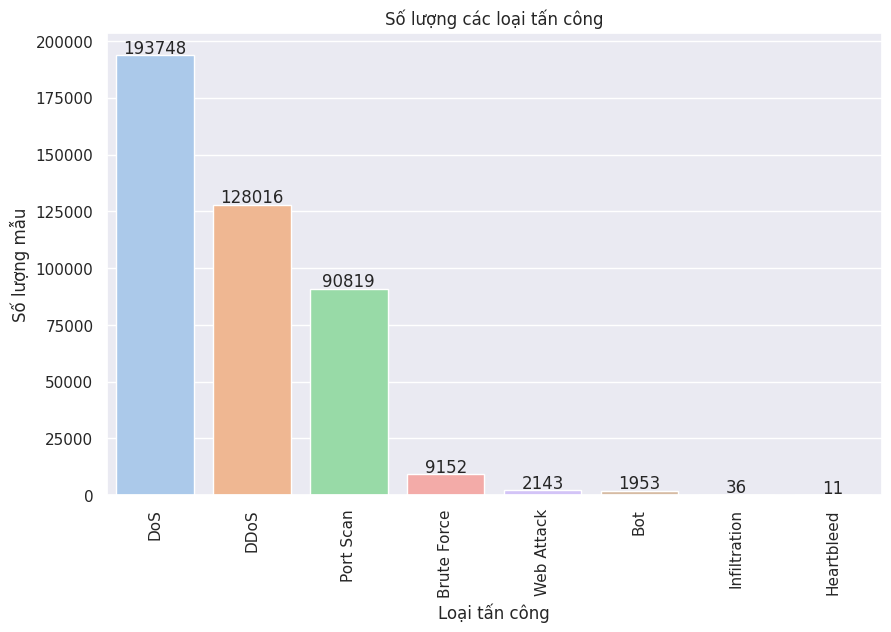

In [ ]:
## Trực quan hóa mối quan hệ giữa các cột
## Phân phối các loại tấn công trong tập dữ liệu chính (loại trừ 'BENIGN')
attacks = data.loc[data['Attack Type'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)
plt.title('Số lượng các loại tấn công')
plt.xlabel('Loại tấn công')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

In [ ]:
## Tối ưu hóa bộ nhớ bằng cách Downcasting kiểu dữ liệu số
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Bộ nhớ tiêu thụ ban đầu: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 sang float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)
        # Downcasting int64 sang int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Bộ nhớ tiêu thụ sau khi tối ưu: {new_memory_usage:.2f} MB')
print(f'Đã giảm được: {((old_memory_usage - new_memory_usage) / old_memory_usage) * 100:.2f}%')

Bộ nhớ tiêu thụ ban đầu: 1520.28 MB
Bộ nhớ tiêu thụ sau khi tối ưu: 789.01 MB
Đã giảm được: 48.10%


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522362 entries, 0 to 2522361
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int32  
 1   Flow Duration                int32  
 2   Total Fwd Packets            int32  
 3   Total Backward Packets       int32  
 4   Total Length of Fwd Packets  int32  
 5   Total Length of Bwd Packets  int32  
 6   Fwd Packet Length Max        int32  
 7   Fwd Packet Length Min        int32  
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        int32  
 11  Bwd Packet Length Min        int32  
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flow IAT Max                 int32  
 19  

In [ ]:
## Loại bỏ các cột chỉ có duy nhất một giá trị (biến hằng số)
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

print('Các cột đã gộp:')
dropped_cols

Các cột đã gộp:


Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [ ]:
data.shape

(2522362, 71)

In [ ]:
## Hiển thị danh sách các cột còn lại sau khi lọc
print(f'Số lượng cột còn lại: {len(data.columns)}')
data.columns

Số lượng cột còn lại: 71


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',

In [ ]:
# Đường dẫn lưu file
export_path = '/content/drive/MyDrive/BTL_TSL_MR/cleaned_data.csv'
# Lưu DataFrame thành CSV (loại bỏ index để file nhẹ hơn)
data.to_csv(export_path, index=False)
print(f'Đã lưu dữ liệu thành công tại: {export_path}')

Đã lưu dữ liệu thành công tại: /content/drive/MyDrive/BTL_TSL_MR/cleaned_data.csv


In [ ]:
data_cleaned = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/cleaned_data.csv')
rows, cols = data_cleaned.shape
print('Kích thước dữ liệu:')
print(f'Số hàng: {rows}')
print(f'Số cột: {cols}')
print(f'Tổng số ô dữ liệu: {rows * cols}')

Kích thước dữ liệu:
Số hàng: 2522362
Số cột: 71
Tổng số ô dữ liệu: 179087702
